## 2022 Pre-doc Data Task
#### Gavin Qu, March 6th 2026

This is an exercise that will test your ability to work with large datasets to draw interesting conclusions and present results in a compelling way. You will be working with the Social Connectedness Index (SCI), a dataset built from an anonymized snapshot of Facebook users and their friendship networks. The data measure the intensity of social connections between counties.

Relevant data: `county_county_sci.tsv`, `sf12010countydistancemiles.csv`.

Our team has a presentation coming up to a set of policymakers in Washtenaw County, Michigan. Using the SCI and the county distance datasets, make a set of exploratory plots describing the social connections of Washtenaw County. Specifically: 

In [1]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("./data/Part1/county_county_sci.tsv", sep='\t')
df2 = pd.read_csv("./data/Part1/sf12010countydistancemiles.csv")

In [2]:
print(f"Shape of df1: {df1.shape}")
print(f"Shape of df2: {df2.shape}")

Shape of df1: (10426441, 3)
Shape of df2: (10371620, 3)


**(a)** Summarize the distribution of Washtenaw's Social Connectedness Index to other counties. County FIPS: 26161

df1 contains user location, friend location, and social connect index between their counties, while df2 contains the distance between each user to their friend's counties and distance. Looking at the mi_to_county column, mean is at 952 miles with min at 1.4 miles and max at 6273 miles distance from Washtenaw county, the median is at 806 miles, standard deviation of 655 miles. Over half of all 10 million records are unique values indicating those are out of the county connections. 

Distribution of Washtenau's SCI to other counties: mean score of 4861, standard deviation of 43914, median of 1933

Plot: Since scaled SCI is a continuous variable I would use kde plot overlay on top of a histogram, since x will be skewed. 

In [3]:
mask = df1['user_loc'] == 26161
df_part_a = df1.loc[mask, :]

print("\nDistribution of social connected index:\n")
print(df_part_a.describe())


Distribution of social connected index:

       user_loc        fr_loc    scaled_sci
count    3229.0   3229.000000  3.229000e+03
mean    26161.0  31514.364819  4.861666e+03
std         0.0  16403.343322  4.391460e+04
min     26161.0   1001.000000  8.200000e+01
25%     26161.0  19039.000000  1.278000e+03
50%     26161.0  30035.000000  1.933000e+03
75%     26161.0  46123.000000  3.020000e+03
max     26161.0  78030.000000  2.345513e+06


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

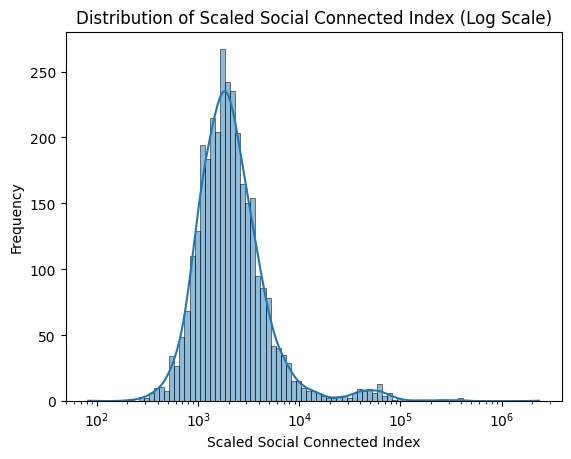

In [5]:
sns.histplot(data=df_part_a, x='scaled_sci', bins='auto', log_scale=True, kde=True)
plt.title('Distribution of Scaled Social Connected Index (Log Scale)')
plt.xlabel('Scaled Social Connected Index')
plt.ylabel('Frequency')
plt.show()

**(b)** Which counties are most strongly connected to Washtenaw? 

`answer:` Below are the top 10 counties based on the scaled_sci score and they are all in Michigan. I included the top 11 because the most connected county is Washtenaw, my guess it's by design due to the scoring system. 

In [6]:
# TODO: find top 10 connected using df_part_a
top_10 = df_part_a.nlargest(11, 'scaled_sci')
# TODO: map to county name using county_description dataset using FIPS code
df3 = pd.read_csv("./data/Part1/county_description.csv")
top_10.merge(df3, left_on='fr_loc', right_on='county_fips', how='inner')

,user_loc,fr_loc,scaled_sci,county_fips,county_name,state_fips,state_name,state_abrev
0,26161,26161,2345513,26161,Washtenaw,26,Michigan,MI
1,26161,26091,406350,26091,Lenawee,26,Michigan,MI
2,26161,26093,378479,26093,Livingston,26,Michigan,MI
3,26161,26075,287758,26075,Jackson,26,Michigan,MI
4,26161,26115,254074,26115,Monroe,26,Michigan,MI
5,26161,26163,223543,26163,Wayne,26,Michigan,MI
6,26161,26125,160393,26125,Oakland,26,Michigan,MI
7,26161,26065,137083,26065,Ingham,26,Michigan,MI
8,26161,26089,98680,26089,Leelanau,26,Michigan,MI
9,26161,26059,97961,26059,Hillsdale,26,Michigan,MI


**(c)** Merge in the distance data and describe the relationship between distance to Washtenaw and connectedness to Washtenaw.
`Answer:` The relationship forms a negative sloping convex plot, as distance to Washtenaw increases, counties connectedness decreases. 

In [7]:
# TODO: left merge df2 with df_part_a on friend location/friend county
mask_c = df2['county1'] == 26161
df_temp = df2.loc[mask_c, :]
df_part_c = df_part_a.merge(df_temp, left_on='fr_loc', right_on='county2', how='left')
df_part_c.head(5)

,user_loc,fr_loc,scaled_sci,county1,mi_to_county,county2
0,26161,1001,2445,26161.0,688.561183,1001.0
1,26161,1003,2851,26161.0,829.571633,1003.0
2,26161,1005,1712,26161.0,722.408813,1005.0
3,26161,1007,1436,26161.0,662.819564,1007.0
4,26161,1009,1378,26161.0,590.491640,1009.0


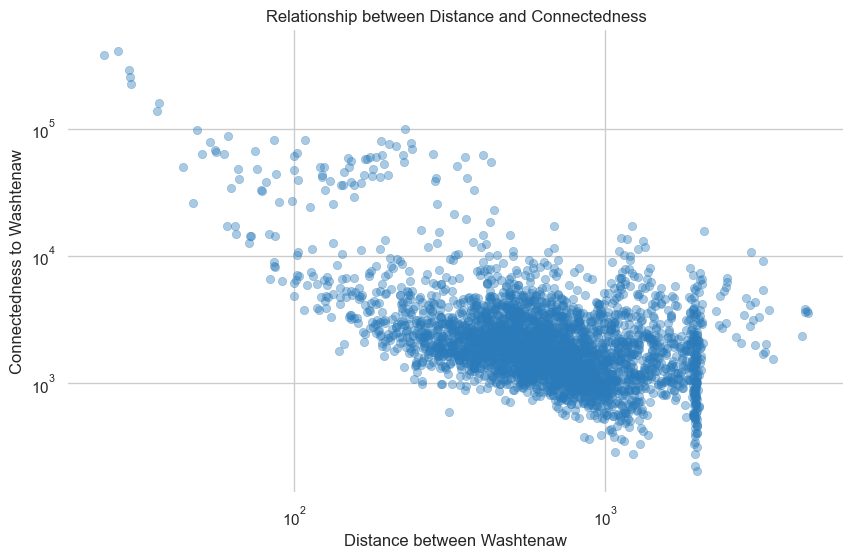

In [9]:
# TODO: scatter plot between distance and connectedness
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_part_c, x='mi_to_county', y='scaled_sci', alpha=0.4, edgecolor=None, color='#2b7bba') #alpha controls transparency 
plt.xscale('log')
plt.yscale('log')

plt.title("Relationship between Distance and Connectedness")
plt.xlabel("Distance between Washtenaw")
plt.ylabel("Connectedness to Washtenaw")
sns.despine(bottom=True, left=True)
plt.show()

The team is also interested in exploring the relationship between a county's network concentration—e.g., the share of a county's Facebook friends that are located nearby—and other important socio-economic measures. For this part: 

**(d)** Using the `county_county_sci.tsv` and `sfl2010countydistancemiles.csv`, construct a county-level measure of network concentration. Briefly justify your measure (there is no single "right" answer). Remember that the social connectedness index is defined as:

$$Social\ Connectedness\ Index_{i,j} = \frac{FB\_Connections_{i,j}}{FB\_Users_{i} \times FB\_Users_{j}}$$

In [10]:
print(f"df1 columns: {df1.columns} \n df2 columns: {df2.columns}")

df1 columns: Index(['user_loc', 'fr_loc', 'scaled_sci'], dtype='str') 
 df2 columns: Index(['county1', 'mi_to_county', 'county2'], dtype='str')


**Network density:** measures how close a network is to being fully connected (actual edges divided by possible edges). 

**Weighted Edges:** The weight between user nodes is measured by the SCI. 

Plan: measure network concentration as the sum of the SCI within a fixed distance (50 miles or median) divided by the sum of all SCIs, this tells us the percentage of county's that is within the 50 miles radius. 

$Concentration_i = \frac{\sum_{j \mid D_{i,j} \le R} SCI_{i,j}}{\sum_{\forall j} SCI_{i,j}}$

In [11]:
# TODO: create the intermediate dyadic dataframe (pairwise)
df_intermediate = df1.merge(
    df2,
    left_on=['user_loc', 'fr_loc'],
    right_on=['county1', 'county2'],
    how='inner'     # drop non existing pairs
)
df_intermediate = df_intermediate.drop(columns=['county1', 'county2'])

# TODO: collapse into the node-level (county) dataframe with d = 50
df_intermediate['local_sci'] = df_intermediate['scaled_sci'].where(df_intermediate['mi_to_county'] <= 50, 0)

df_node = df_intermediate.groupby('user_loc')[['local_sci', 'scaled_sci']].sum().reset_index()  # equivalent of summation notation

df_node['network_concentration'] = df_node['local_sci'] / df_node['scaled_sci']

df_node = df_node.rename(columns={'scaled_sci': 'total_sci'})
print(df_node.head())

   user_loc  local_sci  total_sci  network_concentration
0      1001   19058928   44304624               0.430179
1      1003    2750924   29697903               0.092630
2      1005  118511157  154479850               0.767163
3      1007   24093233   45834951               0.525652
4      1009    9325433   24169304               0.385838


**(e)** Merge in the `county_demographics` dataset and describe relationships between network concentration and 2-3 other county level measures. Suggest possible explanations of why these relationships might exist. Discuss any ideas you have on how your explanations could be tested (perhaps using other data or in other contexts).

In [ ]:
# TODO: convert county_demo df to wide format 
df_demo = pd.read_csv("./data/Part1/county_demographics.csv")

df_demo.head()

,county_fips,measure,value
0,48081,no_highschool_share,0.144813
1,48273,no_highschool_share,0.259427
2,48203,no_highschool_share,0.153767
3,48223,no_highschool_share,0.198011
4,48033,no_highschool_share,0.078571


Data Dictionary 

1. county_county_sci.tsv 

This is the Facebook Social Connectedness Index (SCI). A full description of the data is available here. We include the "US Counties - US Counties" data, a symmetric measure between every pair of US counties. The original data can be found here. The columns are: 

`user_loc` = The FIPS code of the first county (the user's county).

`fr_loc` = The FIPS code of the second county (the friend's county).

`scaled_sci` = The (symmetric) Social Connectedness Index between counties, as detailed in the full description document linked to above.

2. sf12010countydistancemiles.csv 

This is the distance between every county pair (from the NBER). Important: the county pairs between a county and itself are excluded. The columns are: 

`county1` = The FIPS code of the first county.

`omi_to_county` = Miles between the centers countyl and county2.

`county2` = The FIPS code of the second county.

3. county_description.csv 

This is a set of simple county descriptors. The columns are: 

`county_fips` = County FIPS code.

`county_name` = County name.

`state_fips` = State FIPS code.

`state_name` = State name.

`state_abrev` = State abbreviation.

4. county_demographics.csv 

This is a set of county-level demographics and socio-economic outcomes from Bailey et al., 2018. The columns are `county_fips`, `measure`, and `value`. `measure` is one of: 

`no_highschool` = The share of the population that did not attend high school.

`total_population` = The total population.

`male_population` = The male population.

`median_age` = The median age.

`pct_white_alone` = The share of the population that is White alone.

`median_hh_income` = The median household income.

`mean_hh_income` = The mean household income.

`share_below_povline` = The share of the population below the poverty line.

`obama_share_vs_mccain` = Of those who voted for Obama or McCain for president in 2008, the share that voted for Obama.

`cz` = The commuting zone this county falls within.

`e_rank_b` = A measure of upward mobility (i.e., how likely it is for you to have a higher income than your parents). Higher values mean more upward mobility. From Chetty et al. 2020.

`frac_kteenbirthfem` = The teen birth rate.

`sk97` = A measure of social capital (i.e., the general strength of the relationships and trust of people in a county). From Rupasingha et al. 2006.

`le_agg_q[X]_[Y]` = For people of gender Y in this county with incomes in quarter X of the national income distribution, their life expectancy.

## Part 2 

This is an exercise that will test your ability to work with cleaning and processing data. You will work with Twitter data attributed to Russia's Internet Research Agency (IRA) to investigate Russian trolls' tweeting patterns in response to different political events. Since 2016, many journalistic accounts have reported that Russia aimed to stoke polarization on issues related to police violence and race relations. For this exercise, we will explore these claims quantitatively and see whether IRA tweeting patterns really are affected by BLM-related events in the US. Specifically, we'll look at the following events: the death of Freddie Grey on August 19, 2015, Sandra Bland on July 13, 2015, and the Alon Sterling shooting on July 5, 2016.

Relevant data: `ira_tweets_csv_hashed.dta` 

**(a)** Create a panel of the following variables at the day level: 

* Number of tweets.
* Average engagement metrics (replies, likes, quotes, and retweets).
* Number of tweets mentioning either "BLM" or "Black Lives Matter".

In [26]:
# TODO: load data
import pandas as pd

predictors = ['tweet_time', 'retweet_count', 'like_count','quote_count','reply_count', 'tweetid','tweet_text']
tweet = pd.read_csv("./data//Part2/ira_tweets_csv_hashed.csv")
print(f"columns of tweet dataset: {tweet.columns}\n")
print(f"datatype of variables:\n {tweet.loc[:, predictors].dtypes}")

columns of tweet dataset: Index(['tweetid', 'userid', 'user_display_name', 'user_screen_name',
       'user_reported_location', 'user_profile_description',
       'user_profile_url', 'follower_count', 'following_count',
       'account_creation_date', 'account_language', 'tweet_language',
       'tweet_text', 'tweet_time', 'tweet_client_name', 'in_reply_to_tweetid',
       'in_reply_to_userid', 'quoted_tweet_tweetid', 'is_retweet',
       'retweet_userid', 'retweet_tweetid', 'latitude', 'longitude',
       'quote_count', 'reply_count', 'like_count', 'retweet_count', 'hashtags',
       'urls', 'user_mentions', 'poll_choices'],
      dtype='str')

datatype of variables:
 tweet_time           str
retweet_count    float64
like_count       float64
quote_count      float64
reply_count      float64
tweetid          float64
tweet_text           str
dtype: object


/var/folders/n2/8hz3y3r90rj63gkzgrl1hwg40000gn/T/ipykernel_39181/111259296.py:5: DtypeWarning: Columns (0: poll_choices) have mixed types. Specify dtype option on import or set low_memory=False.
  tweet = pd.read_csv("./data//Part2/ira_tweets_csv_hashed.csv")


In [33]:
# convert tweet time to datetime, the floor should be set to day 
tweet['tweet_time'] = pd.to_datetime(tweet['tweet_time'])
tweet['date'] = tweet['tweet_time'].dt.floor('D')

# create boolean flag for blm 
blm_regex = r'\bblm|black lives matter'
tweet['is_blm'] = tweet['tweet_text'].str.contains(blm_regex, case=False, na=False)

# aggregate based on new date column and everything else
daily_panel = tweet.groupby('date').agg(
    tweet_count=('tweetid', 'count'),
    avg_replies=('reply_count', 'mean'),
    avg_retweets=('retweet_count', 'mean'),
    avg_likes=('like_count','mean'),
    avg_quotes=('quote_count', 'mean'),
    contain_blm=('is_blm', 'sum'),
).reset_index()

print(f"{daily_panel.tail(10)}")
print(f"shape of the panel: {daily_panel.shape}")

           date  tweet_count  avg_replies  avg_retweets    avg_likes  \
1599 2018-05-15            2     2.000000      8.500000    56.000000   
1600 2018-05-16            3    10.000000     98.000000   278.333333   
1601 2018-05-17            4    28.500000    547.000000   716.250000   
1602 2018-05-18           11   351.454545    833.454545  2238.909091   
1603 2018-05-21            1     0.000000      0.000000     0.000000   
1604 2018-05-22            3    70.333333    550.666667   976.666667   
1605 2018-05-24            3     5.666667     48.666667   157.333333   
1606 2018-05-25            2     0.000000      0.000000     0.000000   
1607 2018-05-29            3    93.333333    339.666667  1061.000000   
1608 2018-05-30            1     6.000000     89.000000   304.000000   

      avg_quotes  contain_blm  
1599    1.000000            0  
1600    2.333333            0  
1601   30.750000            0  
1602   90.454545            0  
1603    0.000000            0  
1604   79.00000

**(b)** Make a graph that shows the yearly evolution of the 6 variables in your tweets dataset (tweet count, four engagement metrics, tweets about BLM).

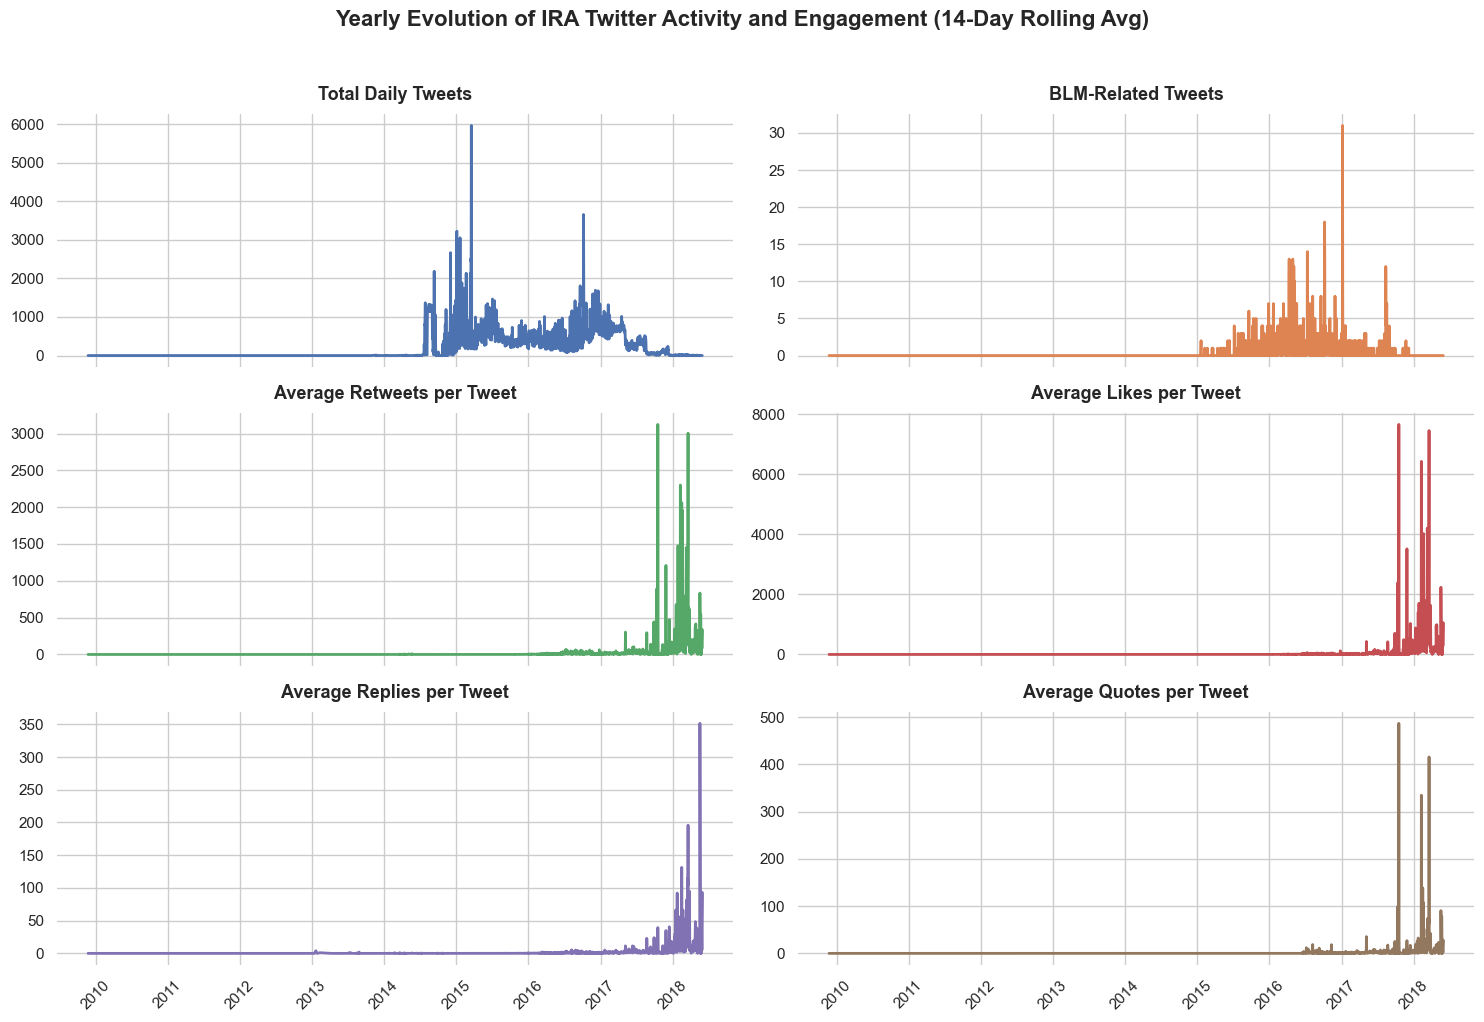

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# use subplot grid and apply rlling avg
sns.set_theme(style='whitegrid', palette='deep')

daily_smooth = daily_panel.set_index('date').rolling('14D').mean().reset_index()

fig, axes = plt.subplots(3, 2, figsize=(15,10), sharex=True)
axes = axes.flatten() # flatten the 2D array into a 1D list of 6 individual axes

metrics = [
    ('tweet_count', 'Total Daily Tweets'),
    ('contain_blm', 'BLM-Related Tweets'),
    ('avg_retweets', 'Average Retweets per Tweet'),
    ('avg_likes', 'Average Likes per Tweet'),
    ('avg_replies', 'Average Replies per Tweet'),
    ('avg_quotes', 'Average Quotes per Tweet')
]

for i, (col, title) in enumerate(metrics):
    sns.lineplot(
        data=daily_panel,
        x='date',
        y=col,
        ax=axes[i],
        linewidth=2,
        color=sns.color_palette()[i % 6] # cycles through distinct colors
    )
    # format subplot
    axes[i].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axes[i].set_ylabel("") # remove default y label
    axes[i].set_xlabel("")

    # Format the x-axis to clearly show the yearly progression
    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45)

sns.despine(left=True,bottom=True)
plt.suptitle("Yearly Evolution of IRA Twitter Activity and Engagement (14-Day Rolling Avg)", 
             fontsize=16, fontweight='bold', y=1.02)

# tight_layout prevents labels from overlapping
plt.tight_layout()
plt.show()

**(c)** Run the following regression: 

$$Y_{t} = \beta_{0} + \beta_{1}X_{t} + \epsilon_{t}$$

where $Y_{t}$ is the outcome variable at time $t$, $X_{t}$ is an indicator that equals 0 during the pre-treatment period and 1 post-treatment. Set the pre/post window as 30 days from the event. Your code should loop over each of the 3 events as well as each of the 6 variables in your tweets dataset (tweet count, four engagement metrics, tweets about BLM).

**(d)** What is the interpretation of each coefficient? 